In [1]:
import sys
sys.path.insert(0, '/global/common/software/lsst/common/miniconda/current/lib/python3.6/site-packages')
import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['font.size'] = 12

from IPython.display import display

from GCR import GCRQuery
import GCRCatalogs

In [2]:
cat = GCRCatalogs.load_catalog('cosmoDC2_v1.1.4_small')
cat.cosmology

AttributeError: 'str' object has no attribute 'name'

In [ ]:
GCRCatalogs.get_available_catalog_names(include_default_only=False)

In [4]:
catalogs = ('cosmoDC2_v1.1.4_image_with_photozs_v1','cosmoDC2_v1.1.4_image_with_photozs_flexzboost_v1')
gc_all = dict(zip(catalogs, (GCRCatalogs.load_catalog(c) for c in catalogs)))


# FlexZBoost

In [5]:
gc_all['cosmoDC2_v1.1.4_image_with_photozs_flexzboost_v1'].list_all_quantities()
[q for q in gc_all['cosmoDC2_v1.1.4_image_with_photozs_flexzboost_v1'].list_all_quantities()
 if 'photo' in q.lower()]
(gc_all['cosmoDC2_v1.1.4_image_with_photozs_flexzboost_v1'].list_all_quantities())


['SDSS_filters/magnitude:SDSS_z:rest',
 'baseDC2/vx',
 'baseDC2/obs_sm',
 'sed_1552_381_disk_no_host_extinction',
 'SEDs/diskLuminositiesStellar:SED_17402_2596:rest',
 'position_angle_true_phosim',
 'mag_i_lsst',
 'SEDs/totalLuminositiesStellar:SED_7385_458:rest',
 'mag_err_y_photoz',
 'SEDs/diskLuminositiesStellar:SED_3590_222:rest:dustAtlas',
 'sed_4048_251',
 'sed_8846_549_bulge_no_host_extinction',
 'SEDs/spheroidLuminositiesStellar:SED_6166_382:rest:dustAtlas',
 'SEDs/totalLuminositiesStellar:SED_3590_222:rest',
 'photoz_mask',
 'SEDs/diskLuminositiesStellar:SED_6548_406:rest',
 'velocity_y',
 'emissionLines/spheroidLineLuminosity:nitrogenII6584',
 'baseDC2/vpeak',
 'sed_13177_1966_no_host_extinction',
 'SEDs/totalLuminositiesStellar:SED_1000_246:rest',
 'SEDs/diskLuminositiesStellar:SED_1246_306:rest',
 'sed_4848_300_disk_no_host_extinction',
 'SEDs/totalLuminositiesStellar:SED_9395_583:rest:dustAtlas',
 'SEDs/spheroidLuminositiesStellar:SED_1000_246:rest:dustAtlas',
 'emissionLi

# BPZ

In [6]:
gc_all['cosmoDC2_v1.1.4_image_with_photozs_v1'].list_all_quantities()
[q for q in gc_all['cosmoDC2_v1.1.4_image_with_photozs_v1'].list_all_quantities()
 if 'photo' in q.lower()]
len(gc_all['cosmoDC2_v1.1.4_image_with_photozs_v1'].list_all_quantities())


898

# Check in three pixels the redshift range 

In [12]:
import numpy as np
import GCRCatalogs

# --------------------------------
# Columns (only what we need)
# --------------------------------
columns = ['redshift', 'photoz_mask']

# --------------------------------
# Load catalogue
# --------------------------------
cat = GCRCatalogs.load_catalog(
    "cosmoDC2_v1.1.4_image_with_photozs_v1"
)

# --------------------------------
# Loop over ONLY three healpix pixels
# --------------------------------
for i, healpix in enumerate(cat.available_healpix_pixels[:3]):

    print(f"\nHealpix {i} — healpix_pixel = {healpix}")

    it = cat.get_quantities(
        columns,
        return_iterator=True,
        native_filters=[f"healpix_pixel == {healpix}"]
    )

    # --------------------------------
    # Loop over ALL chunks
    # --------------------------------
    for j, data in enumerate(it):

        z = data['redshift']
        photoz_mask = data['photoz_mask']

        # Raw redshift range
        zmin_all = np.nanmin(z)
        zmax_all = np.nanmax(z)

        # Photo-z–masked redshift range
        if np.any(photoz_mask):
            z_photo = z[photoz_mask]
            zmin_photo = np.nanmin(z_photo)
            zmax_photo = np.nanmax(z_photo)
        else:
            zmin_photo = np.nan
            zmax_photo = np.nan

        print(
            f"  Chunk {j}: "
            f"z_all = [{zmin_all:.4f}, {zmax_all:.4f}] | "
            f"z_photo = [{zmin_photo:.4f}, {zmax_photo:.4f}]"
        )



Healpix 0 — healpix_pixel = 8786
  Chunk 0: z_all = [0.0136, 1.0178] | z_photo = [0.0136, 1.0178]
  Chunk 1: z_all = [1.0004, 1.9813] | z_photo = [1.0004, 1.9798]
  Chunk 2: z_all = [1.9056, 3.0966] | z_photo = [1.9072, 3.0905]

Healpix 1 — healpix_pixel = 8787
  Chunk 0: z_all = [0.0145, 1.0212] | z_photo = [0.0145, 1.0207]
  Chunk 1: z_all = [0.9981, 1.9759] | z_photo = [0.9981, 1.9751]
  Chunk 2: z_all = [1.9169, 3.1329] | z_photo = [1.9169, 3.1019]

Healpix 2 — healpix_pixel = 8788
  Chunk 0: z_all = [0.0153, 1.0178] | z_photo = [0.0153, 1.0178]
  Chunk 1: z_all = [0.9964, 1.9820] | z_photo = [0.9964, 1.9770]
  Chunk 2: z_all = [1.9118, 3.1016] | z_photo = [1.9146, 3.0847]


In [7]:
import pandas as pd
import GCRCatalogs
import numpy as np

columns = [
    'galaxy_id','halo_id','ra','dec','redshift',
    'mag_r_lsst','mag_g_lsst','stellar_mass','halo_mass','is_central',
    'position_x','position_y','position_z',
    'mag_r_photoz','mag_g_photoz',
    'mag_err_g_photoz','mag_err_r_photoz',
    'photoz_mask','photoz_mean','photoz_mode','photoz_odds',
    'photoz_mode_ml_red_chi2'
]

cat = GCRCatalogs.load_catalog(
    "cosmoDC2_v1.1.4_image_with_photozs_v1"
)

dfs = []

for i, healpix in enumerate(cat.available_healpix_pixels):
    print(f"Healpix iteration {i} — healpix_pixel = {healpix}")

    it = cat.get_quantities(
        columns,
        return_iterator=True,
        native_filters=[f"healpix_pixel == {healpix}"]
    )

    # take only the first chunk
    try:
        data = next(it)
    except StopIteration:
        continue

    # 🔹 build combined mask
    photoz_mask = data['photoz_mask']
    z_mask = data['redshift'] < 0.4
    z_photo = data['redshift'][photoz_mask] < 0.4

    final_mask = photoz_mask & z_mask
    

    newdict = {}
    for key, val in data.items():
        # apply mask only to galaxy-length arrays
        if len(val) == len(final_mask):
            newdict[key] = val[final_mask]
        else:
            newdict[key] = val[z_photo]

    dfs.append(pd.DataFrame(newdict))

# combine at the end (or stream to disk instead)
df_all = pd.concat(dfs, ignore_index=True)


Healpix iteration 0 — healpix_pixel = 8786
Healpix iteration 1 — healpix_pixel = 8787
Healpix iteration 2 — healpix_pixel = 8788
Healpix iteration 3 — healpix_pixel = 8789
Healpix iteration 4 — healpix_pixel = 8790
Healpix iteration 5 — healpix_pixel = 8791
Healpix iteration 6 — healpix_pixel = 8792
Healpix iteration 7 — healpix_pixel = 8793
Healpix iteration 8 — healpix_pixel = 8794
Healpix iteration 9 — healpix_pixel = 8913
Healpix iteration 10 — healpix_pixel = 8914
Healpix iteration 11 — healpix_pixel = 8915
Healpix iteration 12 — healpix_pixel = 8916
Healpix iteration 13 — healpix_pixel = 8917
Healpix iteration 14 — healpix_pixel = 8918
Healpix iteration 15 — healpix_pixel = 8919
Healpix iteration 16 — healpix_pixel = 8920
Healpix iteration 17 — healpix_pixel = 8921
Healpix iteration 18 — healpix_pixel = 9042
Healpix iteration 19 — healpix_pixel = 9043
Healpix iteration 20 — healpix_pixel = 9044
Healpix iteration 21 — healpix_pixel = 9045
Healpix iteration 22 — healpix_pixel = 904

In [13]:
df_filter05= df_all[df_all['redshift']<0.5]
df_filter05.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19154934 entries, 0 to 19154933
Data columns (total 22 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   photoz_mode_ml_red_chi2  float32
 1   dec                      float64
 2   redshift                 float64
 3   position_x               float64
 4   mag_err_g_photoz         float32
 5   mag_err_r_photoz         float32
 6   mag_g_photoz             float32
 7   halo_id                  int64  
 8   mag_g_lsst               float64
 9   photoz_mask              bool   
 10  halo_mass                float64
 11  stellar_mass             float32
 12  photoz_mode              float32
 13  is_central               bool   
 14  position_y               float64
 15  position_z               float64
 16  ra                       float64
 17  mag_r_lsst               float64
 18  mag_r_photoz             float32
 19  photoz_mean              float32
 20  photoz_odds              float32
 21  galaxy

In [14]:
print(len(cat.available_healpix_pixels))

131


(19154,)


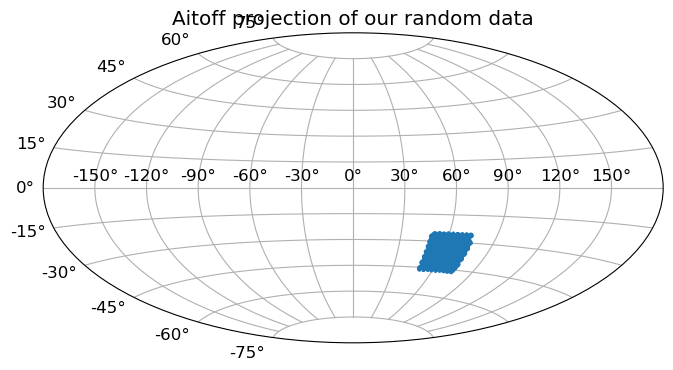

In [15]:
ra = df_filter05['ra']
dec = df_filter05['dec']
ra_rad = np.array(ra)*np.pi/180.
dec_rad = np.array(dec)*np.pi/180.

#seleccion de centros aleatoriamente
k= int(ra_rad.shape[0]/1000)
indices = np.random.randint(0,ra_rad.shape[0],k)
sampled_ra = ra_rad[indices]
sampled_dec = dec_rad[indices]
print(np.shape(sampled_ra))

plt.figure(figsize=(8,4.2))
plt.subplot(111, projection="aitoff")
plt.title("Aitoff projection of our random data")
plt.grid(True)
plt.plot(sampled_ra, sampled_dec, '.', markersize=2, alpha=0.3)
plt.subplots_adjust(top=0.95,bottom=0.0)
plt.show()

In [16]:
galaxy_id = df_filter05['galaxy_id']
halo_id = df_filter05['halo_id']
ra = df_filter05['ra']
dec = df_filter05['dec']
redshift = df_filter05['redshift']

mag_r_lsst = df_filter05['mag_r_lsst']
mag_g_lsst = df_filter05['mag_g_lsst']
stellar_mass = df_filter05['stellar_mass']
halo_mass = df_filter05['halo_mass']
position_x = df_filter05['position_x']
position_y = df_filter05['position_y']
position_z = df_filter05['position_z']

photoz_mean = df_filter05['photoz_mean']
photoz_mode = df_filter05['photoz_mode']
photoz_odds = df_filter05['photoz_odds']

mag_r_photoz = df_filter05['mag_r_photoz']
mag_g_photoz = df_filter05['mag_g_photoz']
mag_err_r_photoz = df_filter05['mag_err_r_photoz']
mag_err_g_photoz = df_filter05['mag_err_g_photoz']

galaxy_id = np.longlong(galaxy_id)
halo_id = np.longlong(halo_id)
ra = np.float32(ra)
dec = np.float32(dec)
redshift = np.float32(redshift)

mag_r_lsst = np.float32(mag_r_lsst)
mag_g_lsst = np.float32(mag_g_lsst)
stellar_mass = np.float32(stellar_mass)
halo_mass = np.float32(halo_mass)
position_x = np.float32(position_x)
position_y = np.float32(position_y)
position_z = np.float32(position_z)

photoz_mean = np.float32(photoz_mean)
photoz_mode = np.float32(photoz_mode)
photoz_odds = np.float32(photoz_odds)

mag_r_photoz = np.float32(mag_r_photoz)
mag_g_photoz = np.float32(mag_g_photoz)
mag_err_r_photoz = np.float32(mag_err_r_photoz)
mag_err_g_photoz = np.float32(mag_err_g_photoz)

is_central_int=np.int32(df_filter05['is_central'])
is_central = is_central_int

import numpy as np
import struct
import os

count = len(galaxy_id)
fout = open('photoz_lsst_large_BPZ_mock_z_lt_0_5.bin','wb')

fout.write(struct.pack('<I', count))

for i in range(count):
  fout.write(struct.pack('<q', galaxy_id[i]))
  fout.write(struct.pack('<q', halo_id[i]))
  fout.write(struct.pack('<f', ra[i]))
  fout.write(struct.pack('<f', dec[i]))
  fout.write(struct.pack('<f', redshift[i]))

  fout.write(struct.pack('<f', mag_r_lsst[i]))
  fout.write(struct.pack('<f', mag_g_lsst[i]))
  fout.write(struct.pack('<f', halo_mass[i]))
  fout.write(struct.pack('<f', stellar_mass[i]))
  fout.write(struct.pack('<I', is_central[i]))
  fout.write(struct.pack('<f', position_x[i]))
  fout.write(struct.pack('<f', position_y[i]))
  fout.write(struct.pack('<f', position_z[i]))

  fout.write(struct.pack('<f', photoz_mean[i]))
  fout.write(struct.pack('<f', photoz_mode[i]))
  fout.write(struct.pack('<f', photoz_odds[i]))

  fout.write(struct.pack('<f', mag_r_photoz[i]))
  fout.write(struct.pack('<f', mag_g_photoz[i]))
  fout.write(struct.pack('<f', mag_err_r_photoz[i]))
  fout.write(struct.pack('<f', mag_err_g_photoz[i]))    
  count -= 1

fout.close()

assert(count == 0)